In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df.shape

(395, 33)

In [8]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


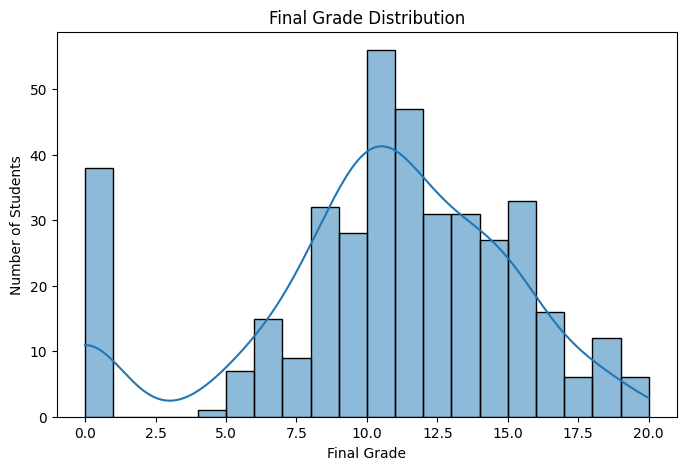

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Final Grade Distribution")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

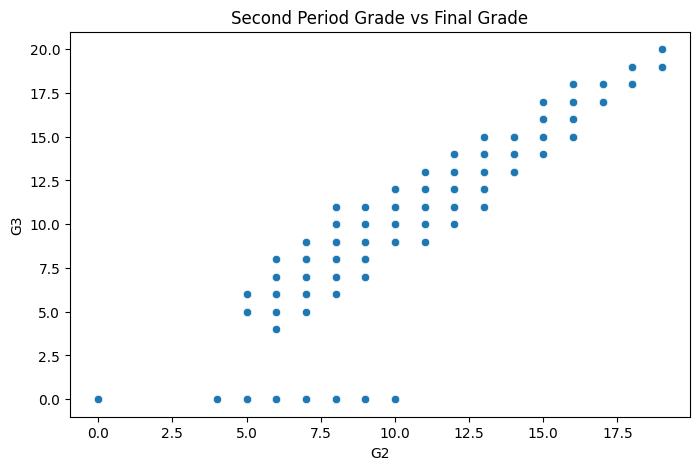

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="G2",
    y="G3"
)

plt.title("Second Period Grade vs Final Grade")
plt.show()

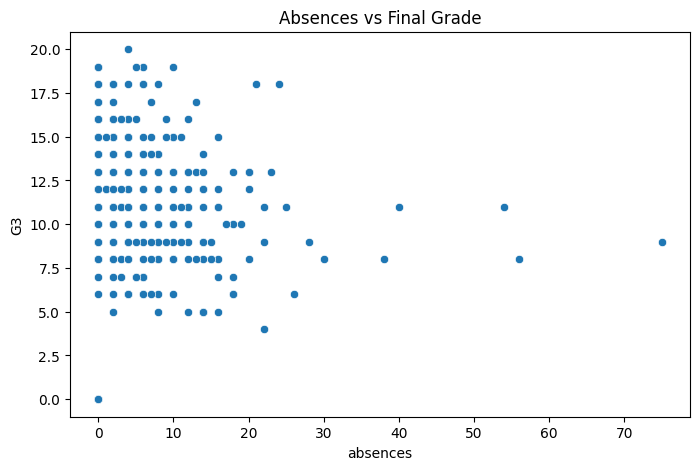

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3"
)

plt.title("Absences vs Final Grade")
plt.show()

In [12]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(395, 33)
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [13]:
features = [
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
    "Medu",
    "Fedu",
    "higher",
    "internet",
    "schoolsup",
    "famsup"
]

target = "G3"

X = df[features]
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['studytime', 'failures', 'absences', 'G1', 'G2', 'Medu', 'Fedu', 'higher', 'internet', 'schoolsup', 'famsup']

Target:
G3


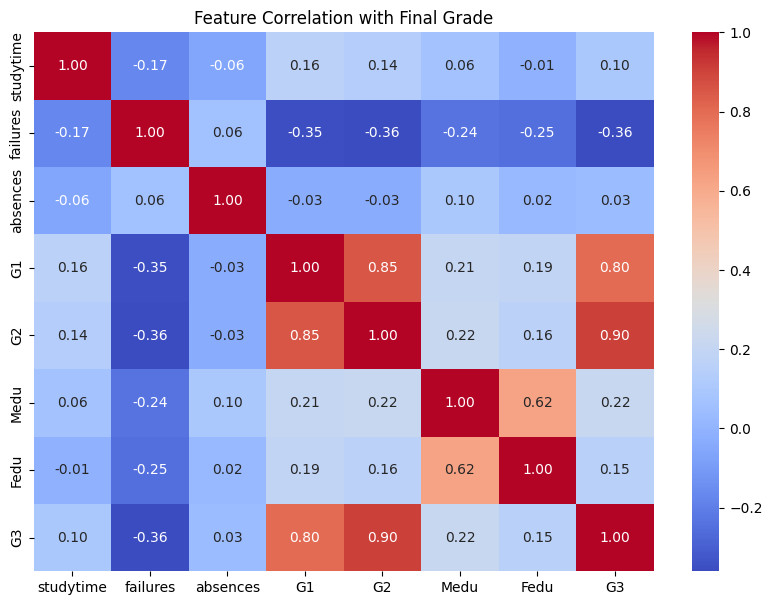

In [14]:
numeric_features = [
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
    "Medu",
    "Fedu",
    "G3"
]

correlation = df[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation with Final Grade")
plt.show()

In [15]:
print(df["G3"].value_counts().sort_index())

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


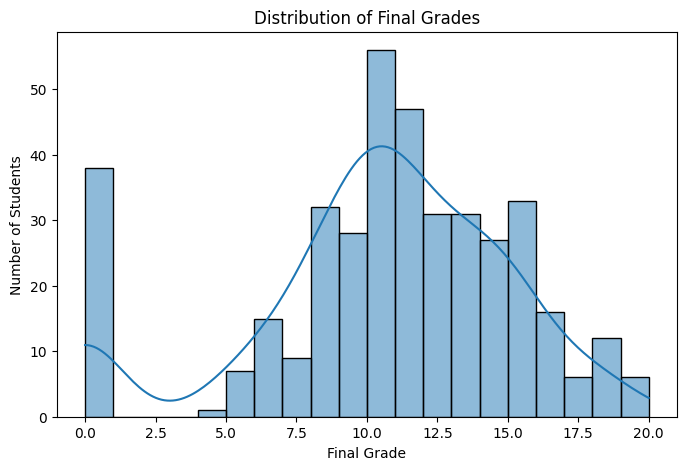

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

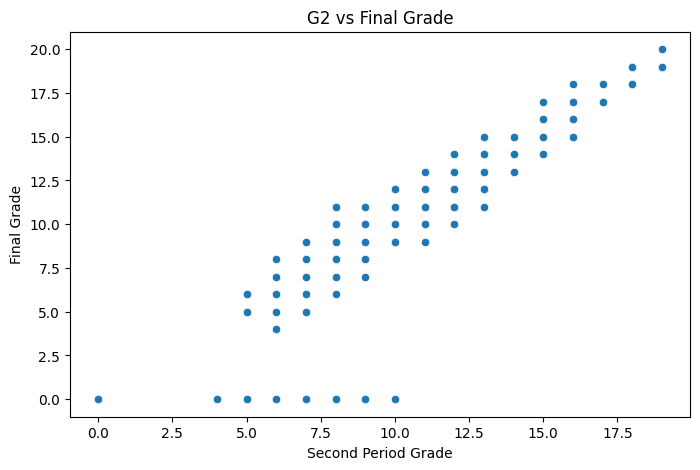

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="G2",
    y="G3"
)

plt.title("G2 vs Final Grade")
plt.xlabel("Second Period Grade")
plt.ylabel("Final Grade")

plt.show()

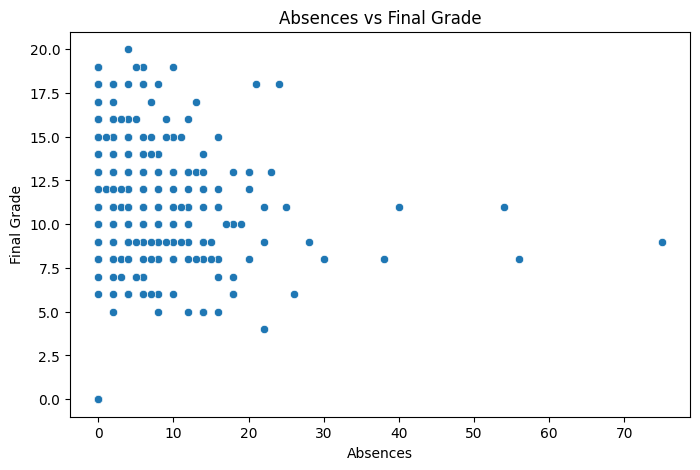

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3"
)

plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")

plt.show()

In [19]:
print(correlation["G3"].sort_values(ascending=False))

G3           1.000000
G2           0.904868
G1           0.801468
Medu         0.217147
Fedu         0.152457
studytime    0.097820
absences     0.034247
failures    -0.360415
Name: G3, dtype: float64


In [20]:
features_early = [
    "studytime",
    "failures",
    "absences",
    "Medu",
    "Fedu",
    "higher",
    "internet",
    "schoolsup",
    "famsup"
]

X_early = df[features_early]
y = df["G3"]

print("X shape:", X_early.shape)
print("y shape:", y.shape)

X shape: (395, 9)
y shape: (395,)


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "higher",
    "internet",
    "schoolsup",
    "famsup"
]

numerical_features = [
    "studytime",
    "failures",
    "absences",
    "Medu",
    "Fedu"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_early,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 9)
Testing data: (79, 9)


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [24]:
y_pred = linear_model.predict(X_test)

print(y_pred[:10])

[ 1.38465909  7.29943309  9.03545623 11.94162662  5.7614565  10.35341206
 11.24460342 10.55011322 10.53989761 10.28116617]


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 3.652262907418502
RMSE: 4.47580679209058
R²: 0.023028516919209263


In [26]:
features_ongoing = [
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
    "Medu",
    "Fedu",
    "higher",
    "internet",
    "schoolsup",
    "famsup"
]

X_ongoing = df[features_ongoing]

X_train, X_test, y_train, y_test = train_test_split(
    X_ongoing,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(316, 11)
(79, 11)


In [27]:
categorical_features = [
    "higher",
    "internet",
    "schoolsup",
    "famsup"
]

numerical_features = [
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
    "Medu",
    "Fedu"
]

preprocessor_ongoing = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [28]:
linear_model_ongoing = Pipeline(
    steps=[
        ("preprocessor", preprocessor_ongoing),
        ("model", LinearRegression())
    ]
)

linear_model_ongoing.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [29]:
y_pred_ongoing = linear_model_ongoing.predict(X_test)

In [30]:
mae_ongoing = mean_absolute_error(y_test, y_pred_ongoing)
rmse_ongoing = np.sqrt(mean_squared_error(y_test, y_pred_ongoing))
r2_ongoing = r2_score(y_test, y_pred_ongoing)

print("MAE:", mae_ongoing)
print("RMSE:", rmse_ongoing)
print("R²:", r2_ongoing)

MAE: 1.4032225291284572
RMSE: 2.1557544166511473
R²: 0.7733593566424757


In [31]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_ongoing),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 1.1424050632911393
RMSE: 1.8813209068179677
R²: 0.8273903830525428


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_ongoing),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

gradient_model.fit(X_train, y_train)

gb_pred = gradient_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)

Gradient Boosting
MAE: 1.1066233009658282
RMSE: 1.8080094943448897
R²: 0.8405807951132035


In [33]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_ongoing,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        rmse_ongoing,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        r2_ongoing,
        rf_r2,
        gb_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,1.403223,2.155754,0.773359
1,Random Forest,1.142405,1.881321,0.827390
2,Gradient Boosting,1.106623,1.808009,0.840581


In [34]:
# Get the fitted preprocessing pipeline
preprocessor_fitted = gradient_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance from Gradient Boosting
importances = gradient_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
12,remainder__G2,0.803766
10,remainder__absences,0.140261
11,remainder__G1,0.020413
14,remainder__Fedu,0.008009
8,remainder__studytime,0.005885
9,remainder__failures,0.005279
5,categorical__schoolsup_yes,0.005206
4,categorical__schoolsup_no,0.004943
13,remainder__Medu,0.004297
7,categorical__famsup_yes,0.000583


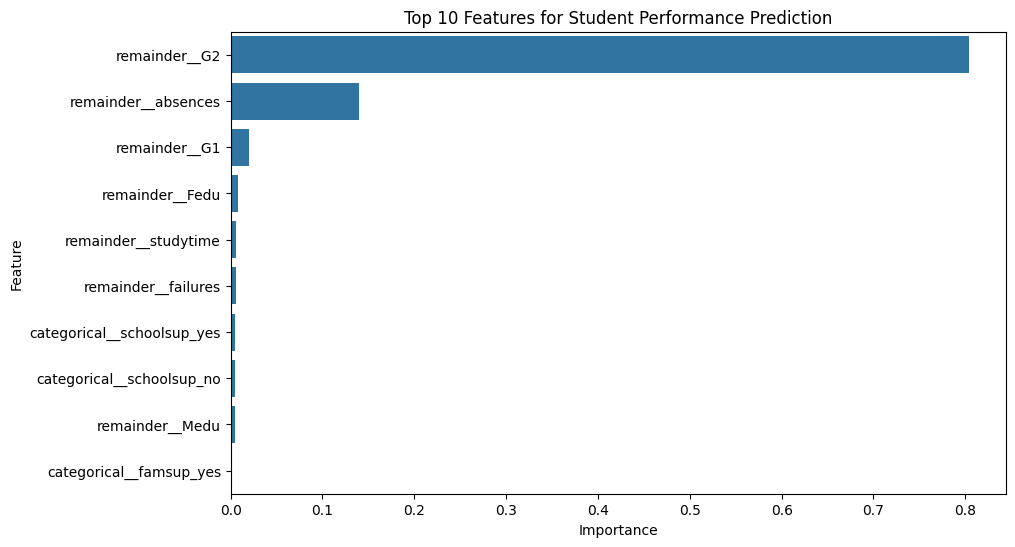

In [35]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features for Student Performance Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [36]:
import joblib

joblib.dump(
    gradient_model,
    "../models/student_performance_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gradient_model,
    X_ongoing,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² scores:")
print(cv_scores)

print("\nMean R²:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation R² scores:
[0.7023776  0.85289942 0.87387342 0.81855439 0.78090559]

Mean R²: 0.8057220854266067
Standard deviation: 0.06054901440892428


In [ ]:
sample_student = pd.DataFrame([{
    "studytime": 3,
    "failures": 0,
    "absences": 4,
    "G1": 14,
    "G2": 15,
    "Medu": 4,
    "Fedu": 3,
    "higher": "yes",
    "internet": "yes",
    "schoolsup": "no",
    "famsup": "yes"
}])

prediction = loaded_model.predict(sample_student)

print("Predicted Final Grade:", prediction[0])

In [40]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_ongoing),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

final_model.fit(X_ongoing, y)

print("Final model trained on complete dataset.")

Final model trained on complete dataset.


In [39]:
import joblib

joblib.dump(
    final_model,
    "../models/student_performance_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [41]:
loaded_model = joblib.load(
    "../models/student_performance_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [42]:
sample_student = pd.DataFrame([{
    "studytime": 3,
    "failures": 0,
    "absences": 4,
    "G1": 14,
    "G2": 15,
    "Medu": 4,
    "Fedu": 3,
    "higher": "yes",
    "internet": "yes",
    "schoolsup": "no",
    "famsup": "yes"
}])

prediction = loaded_model.predict(sample_student)

print("Predicted Final Grade:", prediction[0])

Predicted Final Grade: 15.609224564451523


In [43]:
import sklearn

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.8.0
